# Self-consistent random phase approximation optimized effective potential calculations

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Author:** Egor Trushin  
**Date created:**  11/04/2024  
**Last modified:**  17/07/2025

## 1. Introduction

In this tutorial, I will present examples of self-consistent random phase approximation (SCRPA) optimized effective potential (OEP) calculations using Molpro. These examples are intended to illustrate the main functionality and post-processing of calculations, such as plotting of resulting exchange, correlation and exchange-correlation potentials, accessing eigenvalues, etc. The tutorial is written in Jupyter Notebook. Therefore, I will use Python as a high-level programming language for preparing input files and processing of outputs.  
This tutorial complements the documentation of the SCRPA code in the Molpro manual, which I recommend you read first. I do not describe all possible input options and/or keywords, but concentrate on practical examples.

---

The original implementation of the SCRPA method was described in
> P. Bleiziffer, A. Heßelmann, A. Görling. Efficient self-consistent treatment of electron correlation within the random phase approximation - J. Chem. Phys. 139, 084113 (2013). [link](https://doi.org/10.1063/1.4818984)

The latest state of the method implemented in Molpro is described in
> E. Trushin, S. Fauser, A. Mölkner, J. Erhard, A. Görling. Accurate Correlation Potentials from the Self-Consistent Random Phase Approximation - Phys. Rev. Lett. 134, 016402 (2025). [link](https://doi.org/10.1103/PhysRevLett.134.016402)

The preprocessing of auxiliary basis set was described in
> E. Trushin, A. Görling. Numerically stable optimized effective potential method with standard Gaussian basis sets - J. Chem. Phys. 155, 054109 (2021). [link](https://doi.org/10.1063/5.0056431)  

---

<div class="alert alert-block alert-info"> <b>Important:</b> Read carefully the information below about the selection of basis sets and the thr_fai_oep parameter. </div>

SCRPA calculations requires to specify three basis sets, namely orbital, OEP, and RI basis sets. If density fitting is employed, the corresponding basis sets have to be also specified. The orbital basis set is the primary basis set for e.g. the representation of orbitals and the calculation of energy contributions. The OEP basis set is the auxiliary basis set for representing e.g. the exchange potential. The RI basis set is the basis set, in which the response matrix for the dRPA energy calculation is represented. Gaussian basis set OEP methods for a long time suffered from numerical instabilities resulting from problems in balancing the orbital basis sets with the auxiliary basis sets. Present implementation of RPA-OEP in Molpro use a preprocessing of the auxiliary basis set that enables such balancing in an automatic fashion for standard Gaussian basis sets.The preprocessing step removes linear combinations of auxiliary basis functions that couple poorly to products of occupied times unoccupied Kohn-Sham orbitals. It involves the threshold `thr_fai_oep`, which determines how many linear combinations of auxiliary basis functions are removed and varies with respect to the size of the orbital basis set used. This scheme was tested using Dunning correlation consistent basis sets aug-cc-pwCVXZ (X = T, Q, 5) and recommended thresholds are

| Orbital basis set | **thr_fai_oep** |
| :----: | :----: |
| aug-cc-pwCVTZ  |  5e-2   |
| aug-cc-pwCVQZ  | 1.7e-2  |
| aug-cc-pwCV5Z  |  5e-3   |

These thresholds are also expected to work for orbital basis sets without augmentation cc-pwCVXZ (X = T, Q, 5) and without core-polarization functions aug-cc-pVXZ (X = T, Q, 5).

As an auxiliary basis set (OEP), the aug-cc-pVXZ/mp2fit (X = T, Q, 5) family of basis sets is recommended. In particular, it is recommended to use the aug-cc-pVDZ/mp2fit auxiliary basis sets for atoms up to neon and the aug-cc-pVTZ/mp2fit auxiliary basis sets for heavier atoms.

Def2 basis sets of Ahlrichs family of similar quality also might work, but were not tested extensively in practice.

---

There are two drivers in Molpro to perform RPA-OEP: `SCRPA` and `USCRPA`, for calculation of closed-shell systems and open-shell systems, respectively.

---

Let's start with the import of the required libraries.

In [1]:
# Standard libraries
import os
import numpy as np

# Imports for plotting
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.figsize"] = (5, 4)

The examples in this tutorial are designed to avoid computationally demanding calculations. I use my laptop for all the calculations.  
We can check information about my CPUs.

In [2]:
!lscpu | head -n 12

Architecture:                         x86_64
CPU op-mode(s):                       32-bit, 64-bit
Address sizes:                        48 bits physical, 48 bits virtual
Byte Order:                           Little Endian
CPU(s):                               16
On-line CPU(s) list:                  0-15
Vendor ID:                            AuthenticAMD
Model name:                           AMD Ryzen 9 5900HX with Radeon Graphics
CPU family:                           25
Model:                                80
Thread(s) per core:                   2
Core(s) per socket:                   8


I have Molpro in the directory `/home/trushin/Molpro/molpro`, and I am going to run it with the options `-m 2000 --no-xml-output`. I will store this in a variable for future use.

In [3]:
MOLPRO = "OMP_THREAD_LIMIT=16 /home/trushin/Molpro/molpro/bin/molpro -m 2000 --no-xml-output"

For the future, I will save the directory where this Jupyter Notebook is located.

In [4]:
NOTEBOOK_DIR = os.getcwd()

I also prepare helper functions to read potentials from corresponding data files, parse eigenvalues from the output, and print these eigenvalues.

In [5]:
def load_potential(potfile):
    """Read data from potential-file.

    Args:
      potfile: Path to file with potential data.

    Returns:
      x: x coordinate.
      y: y coordinate.
      z: z coordinate.
      coord: coordinate on path.
      vref: reference potential.
      vrest: rest potential.
      v: full potential.
    """
    x, y, z, coord = list(), list(), list(), list()
    vref, vrest, v = list(), list(), list()
    for line in open(potfile):
        aux = line.split()
        x.append(float(aux[1]))
        y.append(float(aux[2]))
        z.append(float(aux[3]))
        coord.append(float(aux[4]))
        vref.append(float(aux[6]))
        vrest.append(float(aux[7]))
        v.append(float(aux[8]))
    x, y, z, coord = np.array(x), np.array(y), np.array(z), np.array(coord)
    vref, vrest, v = np.array(vref), np.array(vrest), np.array(v)
    return x, y, z, coord, vref, vrest, v

In [6]:
def parse_eigs(outfile):
    """Parse eigenvalues from output.

    Args:
      outfile: Path to output file.

    Returns:
      eigs: List with eigenvalues.
    """
    eigs = []
    l_parse = False
    for line in open(outfile):
        if l_parse:
            for j in line.split()[2:]:
                eigs_aux.append(float(j))
        if "SCRPA eigenvalues" in line:
            l_parse = True
            eigs_aux=[]
        if len(line.split()) == 0 and l_parse:
            l_parse = False
            eigs.append(eigs_aux)

    return eigs

In [7]:
# Function to make text in bold
def bold_text(text): return "\033[1m" + text + "\033[0m"

def print_eigs(eiga, eigb, na, nb, nmax):
    """Function to print eigenvalues.
    
    Args:
      eiga: List with alpha eigenvalues.
      eigb: List with beta eigenvalues.
      na: Number of alpha occupied orbitals.
      nb: Number of beta occupied orbitals.
      nmax: Number of eigenvalues to print.
    """
    for i in range(nmax):
        ea = f"{eiga[i]:7.3f}"
        eb = f"{eigb[i]:7.3f}"
        if i+1 <= na: 
            ea = bold_text(ea)
        if i+1 <= nb:
            eb = bold_text(eb)            
        print(f"{i+1:2}   {ea}  {eb}")

## 2. Calculations for closed-shell systems

### 2.1 H$_2$ molecule

We start with the SCRPA calculation of the closed-shell molecule, H$_2$. We will plot the resulting exchange, correlation, and exchange-correlation potentials along the bond axis. 
Let's create the directory for this calculation and then go to that directory.

In [8]:
os.makedirs("Tutorials/SCRPA/h2", exist_ok=True)
os.chdir("Tutorials/SCRPA/h2/")

Now we write input in file h2.in

In [9]:
%%writefile h2.in
gdirect ! integral-direct mode

basis={
default,aug-cc-pwCVTZ ! orbital basis
set,ri;default,aug-cc-pwCVQZ/mp2fit ! RI BASIS
set,oep;default,aug-cc-pVDZ/mp2fit ! OEP basis
set,dfit;default,aug-cc-pwCV5Z/mp2fit
}

symmetry,nosym ! SCRPA does not use symmetry

angstrom
geometry={
2

H 0.0 0.0 0.370946
H 0.0 0.0 -0.370946
}

df-hf,maxit=0,df_basis=dfit ! HF calculation with 0 iteration
{cfit,basis_coul=dfit,basis_exch=dfit}

acfd;scrpa,thr_fai_oep=5d-2,plot_z=1 ! SCRPA calculation

Writing h2.in


Let's run Molpro calculation.

In [10]:
_ = os.system(f"{MOLPRO} < h2.in > h2.out") # run calculation

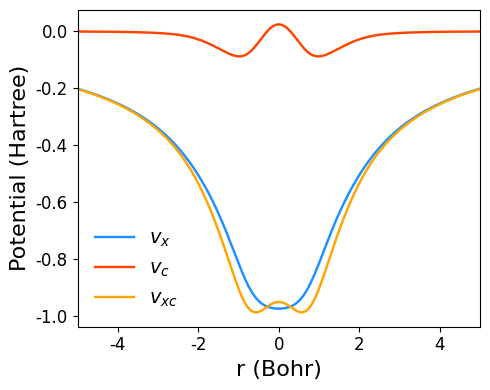

In [11]:
_, _, _, coord, _, _, vx = load_potential('vx-final.z')
_, _, _, coord, _, _, vc = load_potential('vc-final.z')

plt.plot(coord, vx, color='dodgerblue', label='$v_x$')
plt.plot(coord, vc, color='orangered', label='$v_c$')
plt.plot(coord, vx+vc, color='orange', label='$v_{xc}$')

plt.ylabel('Potential (Hartree)', fontsize=16)
plt.xlabel('r (Bohr)', fontsize=16)
plt.xlim(-5, 5)
plt.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.show()

## 3. Calculations for open-shell systems

### 3.1 Li atom: spin-unrestricted calculation

A common way to perform Kohn-Sham (KS) calculations for open-shell systems is based on the spin-unrestricted KS method, which uses two different sets of spatial orbitals for and electrons. This leads to two different effective KS potentials for the $\alpha$- and $\beta$-electrons.

In [12]:
os.chdir(NOTEBOOK_DIR)
os.makedirs("Tutorials/SCRPA/li_u", exist_ok=True)
os.chdir("Tutorials/SCRPA/li_u/")

In [13]:
%%writefile li.in
gdirect ! integral-direct mode

basis={
default,aug-cc-pwCVTZ ! orbital basis
set,ri;default,aug-cc-pwCVQZ/mp2fit ! RI BASIS
set,oep;default,aug-cc-pVDZ/mp2fit ! OEP basis
set,dfit;default,aug-cc-pwCV5Z/mp2fit
}

symmetry,nosym ! USCRPA does not use symmetry

angstrom
geometry={
1

Li 0.0 0.0 0.0
}

spin=1

df-uhf,maxit=0,df_basis=dfit ! HF calculation with 0 iteration
{cfit,basis_coul=dfit,basis_exch=dfit}

acfd;uscrpa,thr_fai_oep=5d-2,plot_z=1 ! USCRPA calculation

Writing li.in


In [14]:
_ = os.system(f"{MOLPRO} < li.in > li.out") # run calculation

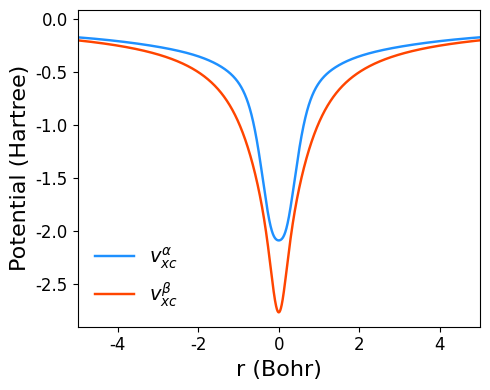

In [15]:
_, _, _, coord, _, _, vxa = load_potential('vxa-final.z')
_, _, _, coord, _, _, vca = load_potential('vca-final.z')

_, _, _, coord, _, _, vxb = load_potential('vxb-final.z')
_, _, _, coord, _, _, vcb = load_potential('vcb-final.z')

plt.plot(coord, vxa+vca, color='dodgerblue', label=r'$v_{xc}^\alpha$')
plt.plot(coord, vxb+vcb, color='orangered', label=r'$v_{xc}^\beta$')

plt.ylabel('Potential (Hartree)', fontsize=16)
plt.xlabel('r (Bohr)', fontsize=16)
plt.xlim(-5, 5)
plt.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
eigs = parse_eigs("li.out")
print("Eigenvalues from spin-unrestricted calculation")
print_eigs(eigs[0], eigs[1], 2, 1, 5)

Eigenvalues from spin-unrestricted calculation
 1    -2.054   -2.421
 2    -0.194   -0.286
 3    -0.123   -0.220
 4    -0.123   -0.220
 5    -0.123   -0.220


In [17]:
!grep "SCRPA Total energy" li.out

 !USCRPA Total energy                  -7.526036234681


### 3.2 Li atom: spin-restricted calculation

An alternative approach to the spin-unrestricted KS method is to use one set of spatial orbitals for electrons of both spins. This approach is often referred to as the spin-restricted KS method for open-shell systems.

In [18]:
os.chdir(NOTEBOOK_DIR)
os.makedirs("Tutorials/SCRPA/li_r", exist_ok=True)
os.chdir("Tutorials/SCRPA/li_r/")

In [19]:
%%writefile li.in
gdirect ! integral-direct mode

basis={
default,aug-cc-pwCVTZ ! orbital basis
set,ri;default,aug-cc-pwCVQZ/mp2fit ! RI BASIS
set,oep;default,aug-cc-pVDZ/mp2fit ! OEP basis
set,dfit;default,aug-cc-pwCV5Z/mp2fit
}

symmetry,nosym ! USCRPA does not use symmetry

angstrom
geometry={
1

Li 0.0 0.0 0.0
}

spin=1

df-uhf,maxit=0,df_basis=dfit ! HF calculation with 0 iteration
{cfit,basis_coul=dfit,basis_exch=dfit}

acfd;uscrpa,thr_fai_oep=5d-2,spin_sym=1,plot_z=1 ! USCRPA calculation

Writing li.in


In [20]:
_ = os.system(f"{MOLPRO} < li.in > li.out") # run calculation

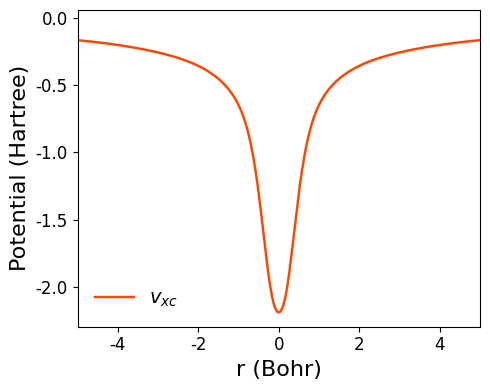

In [21]:
_, _, _, coord, _, _, vx = load_potential('vx-final.z')
_, _, _, coord, _, _, vc = load_potential('vc-final.z')

plt.plot(coord, vx+vc, color='orangered', label='$v_{xc}$')

plt.ylabel('Potential (Hartree)', fontsize=16)
plt.xlabel('r (Bohr)', fontsize=16)
plt.xlim(-5, 5)
plt.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
eigs = parse_eigs("li.out")
print("Eigenvalues from spin-restricted calculation")
print_eigs(eigs[0], eigs[0], 2, 1, 5)

Eigenvalues from spin-restricted calculation
 1    -2.103   -2.103
 2    -0.192   -0.192
 3    -0.122   -0.122
 4    -0.122   -0.122
 5    -0.122   -0.122


In [23]:
!grep "SCRPA Total energy" li.out

 !USCRPA Total energy                  -7.525358532797


## 4. Concluding remarks
In this tutorial, we explored self-consistent random phase approximation calculations using Molpro. We considered both closed- and open-shell systems. For the open-shell system, the Li atom, we performed both spin-unrestricted and spin-restricted calculations.

As a post-processing of calculations, we accessed and printed orbital energies and explored how to plot the resulting exchange-correlation potential and its individual contributions.

---

[![Ask questions](https://img.shields.io/static/v1.svg?logo=star&label=❔&message=Ask%20Questions&color=9cf)](https://github.com/EgorTrushin/Molpro_Tutorials/issues)  For any questions, typos, or bugs that you found, please raise an issue on GitHub.  
[![Star the repository](https://img.shields.io/static/v1.svg?logo=star&label=⭐&message=Star%20the%20Repository&color=yellow)](https://github.com/EgorTrushin/Molpro_Tutorials/)  If you found this tutorial helpful, consider ⭐-ing the repository.